This is notbook used to train a recommndation similar tv shows used in media logger app

# set up

In [ ]:
!pip install tensorflow

In [1]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import pickle


In [2]:
# lets read the data from out json file in to a data frame
tv_show_df = pd.read_json("tv-show.json")

In [3]:
tv_show_df.head(10)

,_id,title,description,averageRating,genre,releaseDate,cast,directors,languages,posterUrl,...,totalSeasons,totalEpisodes,ageRating,youtubeVideoId,tmdbId,imdbId,createdAt,updatedAt,__v,avgRunTime
0,68e2760f50d507e43af606db,Alice in Borderland,"With his two friends, a video-game-obsessed yo...",8.2,"[Mystery, Drama, Action]",2020-12-10T00:00:00.000Z,"[Kento Yamazaki, Tao Tsuchiya, Kotaro Daigo]",[],[japanese],https://image.tmdb.org/t/p/w500/Ac8ruycRXzgcsn...,...,3,22,18.0,EEJ7nUvXUYA,110316,tt10795658,2025-10-05T13:43:43.525Z,2025-10-05T13:43:43.525Z,0,NaN
1,68e2783d6167e55d69eddf59,Peacemaker,"The continuing story of Peacemaker, a vainglor...",8.2,"[Action, Fantasy, Drama]",2022-01-13T00:00:00.000Z,"[John Cena, Danielle Brooks, Freddie Stroma, J...",[James Gunn],[english],https://image.tmdb.org/t/p/w500/yb4F1Oocq8GfQt...,...,2,16,17.0,O9DAiLI7Cn8,110492,tt13146488,2025-10-05T13:53:01.467Z,2025-10-05T13:53:01.467Z,0,NaN
2,68e2813a5df69ce8e15fb6a9,Kaiju No. 8,In a world plagued by creatures known as Kaiju...,8.5,"[Animation, Action, Fantasy]",2024-04-13T00:00:00.000Z,"[Masaya Fukunishi, Asami Seto, Wataru Katoh, F...",[],[japanese],https://image.tmdb.org/t/p/w500/bJxGs0w5RAhaX4...,...,1,23,14.0,FsAKMsUjaK0,207468,tt21975436,2025-10-05T14:31:22.972Z,2025-10-05T14:31:22.972Z,0,24.0
3,68e2813b5df69ce8e15fb6db,Prison Break,"Due to a political conspiracy, an innocent man...",8.1,"[Action, Crime, Drama]",2005-08-29T00:00:00.000Z,"[Wentworth Miller, Dominic Purcell, Sarah Wayn...",[Paul T. Scheuring],[english],https://image.tmdb.org/t/p/w500/z885tJn5kkUHpp...,...,5,88,0.0,AL9zLctDJaU,2288,tt0455275,2025-10-05T14:31:23.731Z,2025-10-05T14:31:23.731Z,0,45.0
4,68e2813e5df69ce8e15fb797,Family Guy,"Sick, twisted, politically incorrect and Freak...",7.4,"[Animation, Comedy]",1999-01-31T00:00:00.000Z,"[Seth MacFarlane, Alex Borstein, Mila Kunis, S...",[Seth MacFarlane],[english],https://image.tmdb.org/t/p/w500/8o8kiBkWFK3gVy...,...,23,441,16.0,J32iwo65RMc,1434,tt0182576,2025-10-05T14:31:26.107Z,2025-10-05T14:31:26.107Z,0,22.0
5,68e2814b5df69ce8e15fbb39,Gen V,"At America's only college for superheroes, gif...",7.7,"[Action, Drama, Fantasy]",2023-09-28T00:00:00.000Z,"[Jaz Sinclair, Lizze Broadway, Maddie Phillips...","[Craig Rosenberg, Evan Goldberg, Eric Kripke]",[english],https://image.tmdb.org/t/p/w500/tEv842Nd5uMSav...,...,2,16,17.0,uhjJ5brX-bY,205715,tt13159924,2025-10-05T14:31:39.923Z,2025-10-05T14:31:39.923Z,0,NaN
6,68e2814c5df69ce8e15fbb5f,House,"Dr. Gregory House, a drug-addicted, unconventi...",8.6,"[Drama, Mystery, Comedy]",2004-11-16T00:00:00.000Z,"[Hugh Laurie, Robert Sean Leonard, Omar Epps, ...",[David Shore],[english],https://image.tmdb.org/t/p/w500/3Cz7ySOQJmqiuT...,...,8,176,0.0,MczMB8nU1sY,1408,tt0412142,2025-10-05T14:31:40.391Z,2025-10-05T14:31:40.391Z,0,44.0
7,68e281515df69ce8e15fbcd1,FROM,Unravel the mystery of a nightmarish town in m...,8.2,"[Mystery, Drama, Fantasy]",2022-02-20T00:00:00.000Z,"[Harold Perrineau, Catalina Sandino Moreno, Ei...",[John Griffin],[english],https://image.tmdb.org/t/p/w500/cjXLrg4R7FRPFa...,...,4,30,17.0,pDHqAj4eJcM,124364,tt9813792,2025-10-05T14:31:45.128Z,2025-10-05T14:31:45.128Z,0,NaN
8,68e281525df69ce8e15fbd17,"Bon Appétit, Your Majesty","After time traveling to the Joseon era, a tale...",8.8,"[Fantasy, Drama]",2025-08-23T00:00:00.000Z,"[Yoona, Lee Chae-min, Kang Hanna, Choi Gwi-hwa...",[Jang Tae-yoo],"[korean, mandarin]",https://image.tmdb.org/t/p/w500/xnDFKpPeANnUaR...,...,1,12,13.0,rkB623sLOiM,280945,tt37600136,2025-10-05T14:31:46.082Z,2025-10-05T14:31:46.082Z,0,80.0
9,68e281525df69ce8e15fbd33,The Blacklist,"Raymond ""Red"" Reddington, one of the FBI's mos...",7.6,"[Drama, Crime, Mystery]",2013-09-23T00:00:00.000Z,"[James Spader, Diego Klattenhoff, Hisham Tawfi...",[Jon Bokenkamp],[english],https://image.tmdb.org/t/p/w500/4HTfd1PhgFUenJ...,...,10,218,0.0,JGBIimq1I3A,46952,tt2741602,2025-10-05T14:31:46.430Z,2025-10-05T14:31:46.430Z,0,NaN


# **Data processing**

In [4]:
tv_show_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _id             51 non-null     object 
 1   title           51 non-null     object 
 2   description     51 non-null     object 
 3   averageRating   51 non-null     float64
 4   genre           51 non-null     object 
 5   releaseDate     51 non-null     object 
 6   cast            51 non-null     object 
 7   directors       51 non-null     object 
 8   languages       51 non-null     object 
 9   posterUrl       51 non-null     object 
 10  backdropUrl     51 non-null     object 
 11  isActive        51 non-null     bool   
 12  status          51 non-null     object 
 13  tags            51 non-null     object 
 14  totalSeasons    51 non-null     int64  
 15  totalEpisodes   51 non-null     int64  
 16  ageRating       48 non-null     float64
 17  youtubeVideoId  51 non-null     objec

lets convert the date to datetime

In [5]:
tv_show_df["releaseDate"] = pd.to_datetime(tv_show_df["releaseDate"] , errors="coerce")
tv_show_df["createdAt"] = pd.to_datetime(tv_show_df["createdAt"] , errors="coerce")
tv_show_df["updatedAt"] = pd.to_datetime(tv_show_df["updatedAt"] , errors="coerce")

tv_show_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             51 non-null     object             
 1   title           51 non-null     object             
 2   description     51 non-null     object             
 3   averageRating   51 non-null     float64            
 4   genre           51 non-null     object             
 5   releaseDate     51 non-null     datetime64[ns, UTC]
 6   cast            51 non-null     object             
 7   directors       51 non-null     object             
 8   languages       51 non-null     object             
 9   posterUrl       51 non-null     object             
 10  backdropUrl     51 non-null     object             
 11  isActive        51 non-null     bool               
 12  status          51 non-null     object             
 13  tags            51 non-null     objec

# **Visualization**

## Distribution

lets focus on plotting distribution of all the numeric values


In [ ]:
num_columns = tv_show_df.select_dtypes(include='number')
num_columns.columns

Index(['averageRating', 'totalSeasons', 'totalEpisodes', 'ageRating', 'tmdbId',
       '__v', 'avgRunTime'],
      dtype='object')

### Age Rating

Text(0.5, 1.0, 'Age rating vs count')

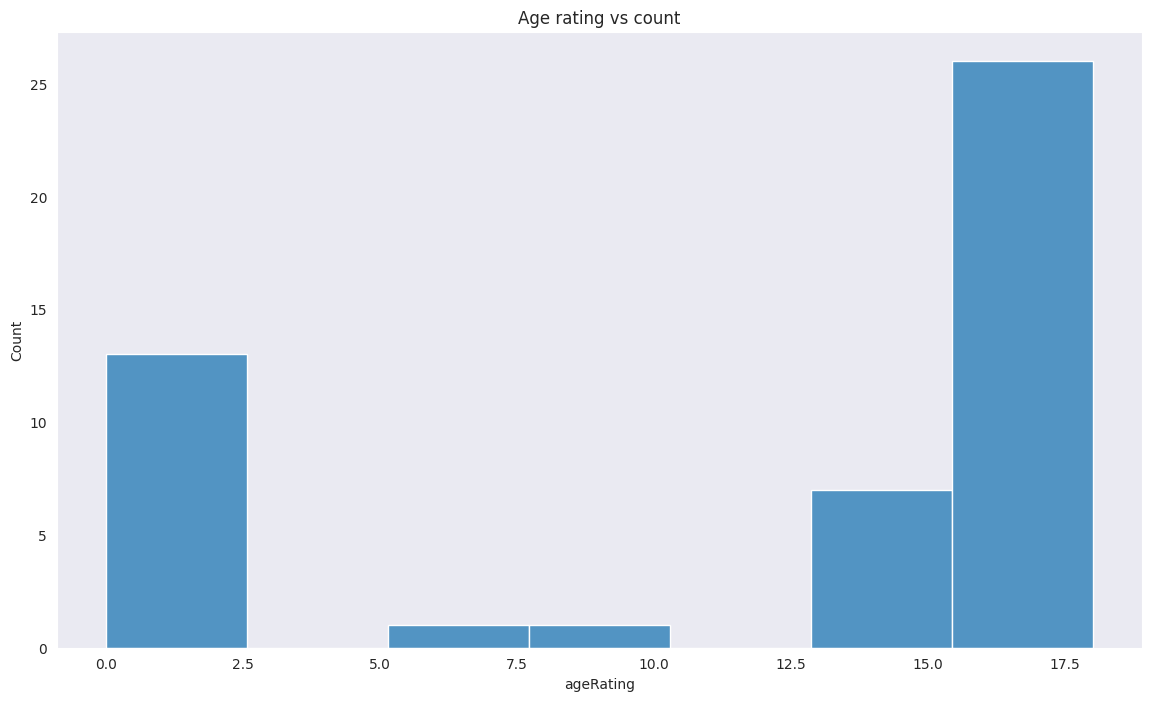

In [7]:
# lets have a hist plot of age rating against count
sns.set_style("dark");
plt.figure(figsize=(14, 8));

sns.histplot(x = "ageRating" , data=tv_show_df)
plt.title('Age rating vs count')

Text(0.5, 1.0, 'Age rating vs count')

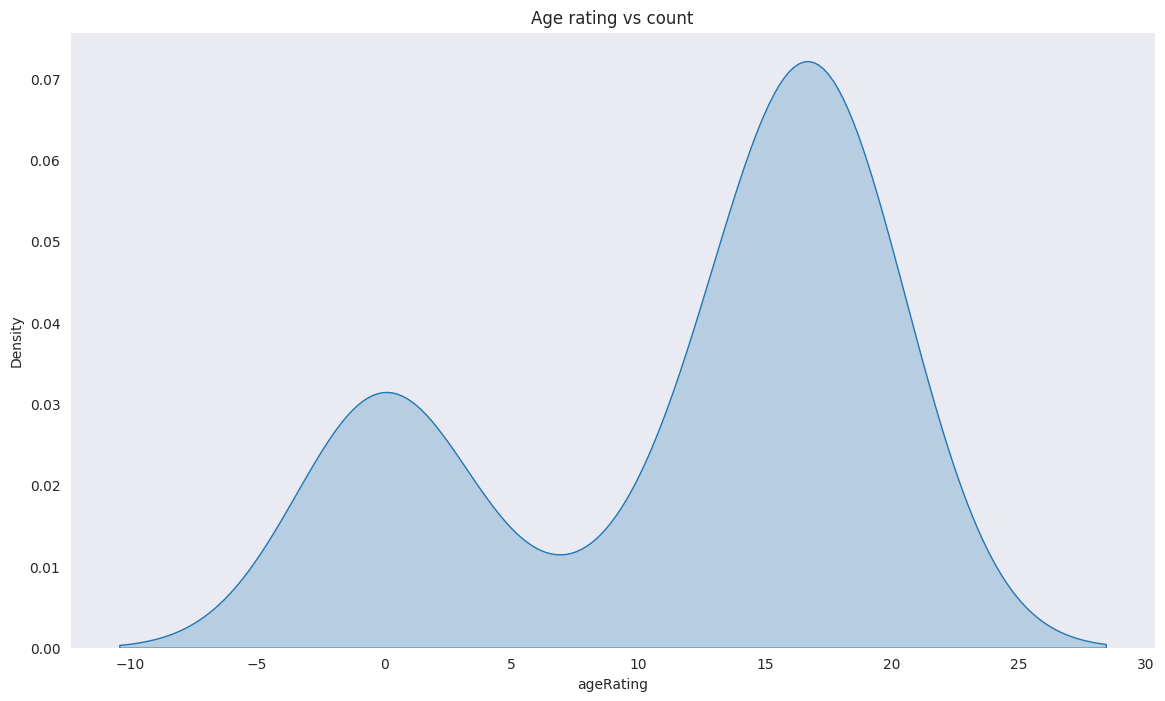

In [16]:
#kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x = "ageRating" , data=tv_show_df , fill=True)
plt.title('Age rating vs count')

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

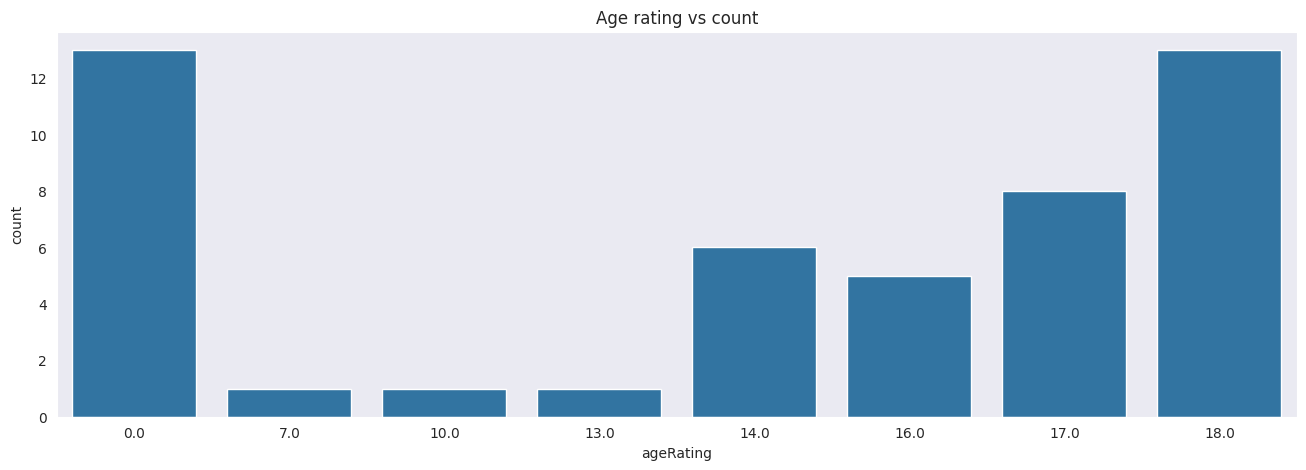

In [17]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = tv_show_df)

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

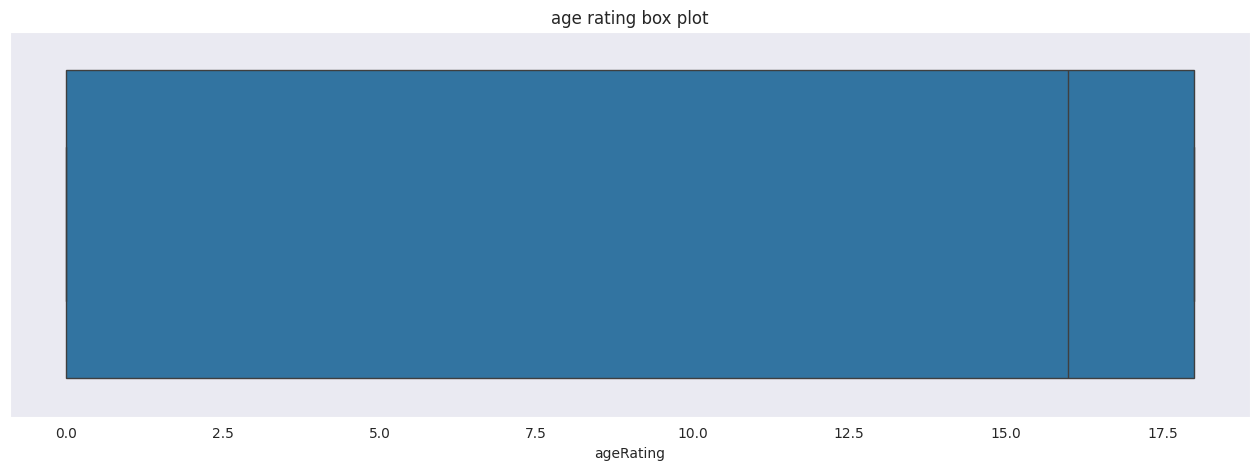

In [18]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=tv_show_df["ageRating"])

majority in range of 15 to 20 , the initial 0 values are also taken as nan or unrated .will has to be imputed for training.

### **Average rating**